In [1]:
def read_network(path):
    structure = []
    f = open(path, "r")
    n_layers = int(f.readline().strip())
    for _ in range(n_layers):
        structure.append(int(f.readline().strip()))
    f.close()
    return structure

structure = read_network("nn_input.txt")
print("Network structure:", structure)
print(f"  Input layer:  {structure[0]} neurons")
for i in range(1, len(structure) - 1):
    print(f"  Hidden layer {i}: {structure[i]} neurons")
print(f"  Output layer: {structure[-1]} neurons")

Network structure: [2, 2, 1]
  Input layer:  2 neurons
  Hidden layer 1: 2 neurons
  Output layer: 1 neurons


In [2]:
import math

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

In [3]:
class Neuron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def forward(self, inputs):
        z = sum(w * x for w, x in zip(self.weights, inputs)) + self.bias
        a = sigmoid(z)
        return z, a

In [4]:
class Layer:
    def __init__(self, neurons):
        self.neurons = neurons

    def forward(self, inputs):
        zs = []
        acts = []
        for n in self.neurons:
            z, a = n.forward(inputs)
            zs.append(z)
            acts.append(a)
        return zs, acts

In [5]:
import random

class NeuralNetwork:
    def __init__(self, structure):
        self.structure = structure
        self.layers = []
        for i in range(1, len(structure)):
            n_in = structure[i - 1]
            n_out = structure[i]
            neurons = [Neuron([0.0] * n_in, 0.0) for _ in range(n_out)]
            self.layers.append(Layer(neurons))

    def init_random(self):
        for layer in self.layers:
            for neuron in layer.neurons:
                neuron.weights = [random.random() for _ in neuron.weights]
                neuron.bias = random.random()

    def forward(self, x):
        a = x
        all_z = []
        all_a = [x]
        for layer in self.layers:
            zs, a = layer.forward(a)
            all_z.append(zs)
            all_a.append(a)
        return all_z, all_a

In [6]:
nn = NeuralNetwork(structure)
nn.init_random()
print("Random initialization:")
for l, layer in enumerate(nn.layers):
    for n_idx, neuron in enumerate(layer.neurons):
        print(f"  Layer {l+1}, Neuron {n_idx+1}: w={[round(w, 4) for w in neuron.weights]}, b={round(neuron.bias, 4)}")

Random initialization:
  Layer 1, Neuron 1: w=[0.2518, 0.6816], b=0.2236
  Layer 1, Neuron 2: w=[0.8635, 0.7454], b=0.9819
  Layer 2, Neuron 1: w=[0.9291, 0.2501], b=0.9388


In [7]:
nn.layers[0].neurons[0].weights = [20.0, 20.0]
nn.layers[0].neurons[0].bias = -10.0
nn.layers[0].neurons[1].weights = [20.0, 20.0]
nn.layers[0].neurons[1].bias = -30.0
nn.layers[1].neurons[0].weights = [20.0, -20.0]
nn.layers[1].neurons[0].bias = -10.0

xor_inputs = [[0, 0], [0, 1], [1, 0], [1, 1]]
xor_labels = [0, 1, 1, 0]

print("XOR forward pass:")
print(f"{'x1':>4} {'x2':>4} {'y':>4} {'y_hat':>8} {'pred':>6}")
print("-" * 35)
for x, y in zip(xor_inputs, xor_labels):
    _, all_a = nn.forward(x)
    y_hat = all_a[-1][0]
    pred = 1 if y_hat >= 0.5 else 0
    print(f"{x[0]:>4} {x[1]:>4} {y:>4} {y_hat:>8.4f} {pred:>6}")

XOR forward pass:
  x1   x2    y    y_hat   pred
-----------------------------------
   0    0    0   0.0000      0
   0    1    1   1.0000      1
   1    0    1   1.0000      1
   1    1    0   0.0000      0


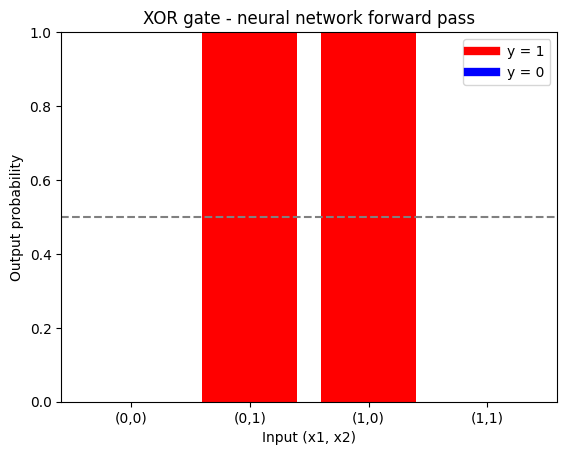

In [8]:
import matplotlib.pyplot as plt

outputs = []
for x in xor_inputs:
    _, all_a = nn.forward(x)
    outputs.append(all_a[-1][0])

labels_str = ["(0,0)", "(0,1)", "(1,0)", "(1,1)"]
colors = ["blue" if y == 0 else "red" for y in xor_labels]

plt.bar(labels_str, outputs, color=colors)
plt.axhline(0.5, color="gray", linestyle="--", label="threshold = 0.5")
plt.ylim(0, 1)
plt.xlabel("Input (x1, x2)")
plt.ylabel("Output probability")
plt.title("XOR gate - neural network forward pass")
plt.legend(handles=[
    plt.Line2D([0], [0], color="red", linewidth=6, label="y = 1"),
    plt.Line2D([0], [0], color="blue", linewidth=6, label="y = 0")
])
plt.savefig("neural_network.png")
plt.show()

In [9]:
def read_csv(path):
    X, Y = [], []
    f = open(path, "r")
    first = True
    for line in f:
        line = line.strip()
        if line == "" or first:
            first = False
            continue
        parts = [float(v) for v in line.split(",")]
        X.append(parts[:-1])
        Y.append(parts[-1])
    f.close()
    return X, Y

def init_uniform(nn, seed=None):
    if seed is not None:
        random.seed(seed)
    for layer in nn.layers:
        for neuron in layer.neurons:
            neuron.weights = [random.uniform(-1, 1) for _ in neuron.weights]
            neuron.bias = random.uniform(-1, 1)

In [10]:
def backward(self, x, y, lr):
    x1, x2 = x[0], x[1]
    _, all_a = self.forward(x)
    a1_1, a2_1 = all_a[1][0], all_a[1][1]
    y_hat = all_a[2][0]

    n1    = self.layers[0].neurons[0]
    n2    = self.layers[0].neurons[1]
    n_out = self.layers[1].neurons[0]

    w11_2, w21_2 = n_out.weights[0], n_out.weights[1]

    e_out = y_hat - y
    e_h1  = (w11_2 * e_out) * a1_1 * (1 - a1_1)
    e_h2  = (w21_2 * e_out) * a2_1 * (1 - a2_1)

    n_out.weights[0] -= lr * a1_1 * e_out
    n_out.weights[1] -= lr * a2_1 * e_out
    n_out.bias       -= lr * e_out

    n1.weights[0] -= lr * x1 * e_h1
    n1.weights[1] -= lr * x2 * e_h1
    n1.bias       -= lr * e_h1
    n2.weights[0] -= lr * x1 * e_h2
    n2.weights[1] -= lr * x2 * e_h2
    n2.bias       -= lr * e_h2

def loss(self, X, Y):
    total = 0.0
    for x, y in zip(X, Y):
        _, all_a = self.forward(x)
        y_hat = max(1e-9, min(1 - 1e-9, all_a[-1][0]))
        total += -(y * math.log(y_hat) + (1 - y) * math.log(1 - y_hat))
    return total / len(X)

def train(self, X, Y, lr, epochs):
    history = []
    for epoch in range(epochs):
        for x, y in zip(X, Y):
            self.backward(x, y, lr)
        if (epoch + 1) % 500 == 0 or epoch == 0:
            J = self.loss(X, Y)
            history.append((epoch + 1, J))
            print(f"Epoch {epoch + 1}: J = {J:.4f}")
    return history

NeuralNetwork.backward = backward
NeuralNetwork.loss = loss
NeuralNetwork.train = train

In [11]:
X_xor = [[0, 0], [0, 1], [1, 0], [1, 1]]
Y_xor = [0.0, 1.0, 1.0, 0.0]

init_uniform(nn, seed=2)
print("Training XOR (lr=0.5, epochs=5000)...")
history_xor = nn.train(X_xor, Y_xor, lr=0.5, epochs=5000)

print(f"\n{'x1':>4} {'x2':>4} {'y':>4} {'y_hat':>8} {'pred':>6}")
print("-" * 35)
for x, y in zip(X_xor, Y_xor):
    _, all_a = nn.forward(x)
    y_hat = all_a[-1][0]
    pred = 1 if y_hat >= 0.5 else 0
    print(f"{x[0]:>4.0f} {x[1]:>4.0f} {y:>4.0f} {y_hat:>8.4f} {pred:>6}")

Training XOR (lr=0.5, epochs=5000)...
Epoch 1: J = 0.6926
Epoch 500: J = 0.0235
Epoch 1000: J = 0.0070
Epoch 1500: J = 0.0040
Epoch 2000: J = 0.0028
Epoch 2500: J = 0.0022
Epoch 3000: J = 0.0018
Epoch 3500: J = 0.0015
Epoch 4000: J = 0.0013
Epoch 4500: J = 0.0011
Epoch 5000: J = 0.0010

  x1   x2    y    y_hat   pred
-----------------------------------
   0    0    0   0.0009      0
   0    1    1   0.9989      1
   1    0    1   0.9989      1
   1    1    0   0.0009      0


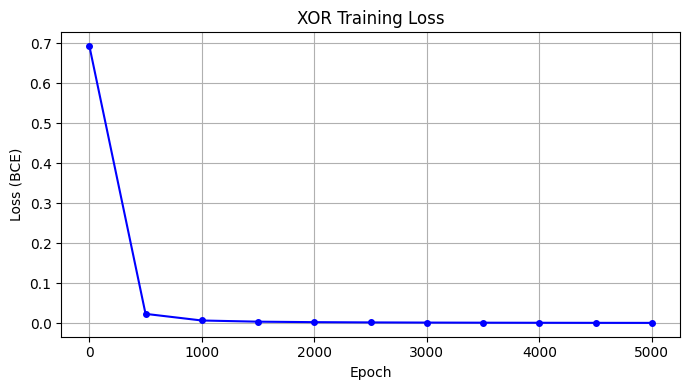

In [12]:
epochs_xor = [h[0] for h in history_xor]
losses_xor = [h[1] for h in history_xor]

plt.figure(figsize=(7, 4))
plt.plot(epochs_xor, losses_xor, 'b-o', markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.title("XOR Training Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("../Image/xor_loss.png")
plt.show()

In [13]:
X_house, Y_house = read_csv("../Dataset/house.csv")

nn_house = NeuralNetwork(structure)
init_uniform(nn_house, seed=42)
print("Training house (lr=0.5, epochs=1000)...")
history_house = nn_house.train(X_house, Y_house, lr=0.5, epochs=1000)

print(f"\n{'size':>6} {'price':>6} {'y':>4} {'y_hat':>8} {'pred':>6}")
print("-" * 40)
for x, y in zip(X_house, Y_house):
    _, all_a = nn_house.forward(x)
    y_hat = all_a[-1][0]
    pred = 1 if y_hat >= 0.5 else 0
    print(f"{x[0]:>6.2f} {x[1]:>6.2f} {y:>4.0f} {y_hat:>8.4f} {pred:>6}")

Training house (lr=0.5, epochs=1000)...
Epoch 1: J = 0.7674
Epoch 500: J = 0.0037
Epoch 1000: J = 0.0016

  size  price    y    y_hat   pred
----------------------------------------
  0.20   0.18    0   0.0000      0
  0.25   0.22    0   0.0000      0
  0.35   0.30    0   0.0000      0
  0.45   0.40    0   0.0002      0
  0.50   0.48    0   0.0081      0
  0.60   0.62    1   0.9922      1
  0.70   0.72    1   0.9999      1
  0.75   0.78    1   1.0000      1
  0.85   0.88    1   1.0000      1
  0.90   0.92    1   1.0000      1


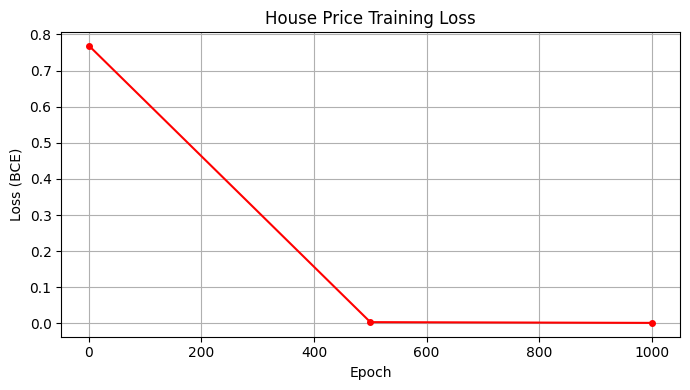

In [14]:
epochs_house = [h[0] for h in history_house]
losses_house = [h[1] for h in history_house]

plt.figure(figsize=(7, 4))
plt.plot(epochs_house, losses_house, 'r-o', markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.title("House Price Training Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("../Image/house_loss.png")
plt.show()